<h1 style="font-size: 0; line-height: 0; height: 0; margin: 0; padding: 0;">&#8203;</h1>
<center><img align="center" src="https://www.sydney.edu.au/content/dam/icons/logos/logo-usyd-dark.svg"></center>
<h1 align="center" style="margin-top:10px">QBUS3830 Advanced Analytics</h1>
<h2 align="center" style="margin-top:20px">Week 6 Tutorial: Uncertainty Quantification</h2>
<br>

### Business problem

You are the analyst for a supermarket. Each morning the buyer must commit to an order
quantity for a fresh product at one store. Anything left unsold at close is written off
at a loss of $\$2$ per unit; anything the store runs out of costs $\$4$ in forgone
margin.

In Week 1 you showed that these two numbers make the order quantity a **quantile**. The
optimal order sits at the **2/3 quantile of demand**.

Today, the category manager asks two questions:

> *How sure are you about that order quantity?*
>
> *And what range of demand should expect on a given day?*

These are different questions. The first is about a quantity we **estimated** from data.
The second is about an **future outcome**. 
### What you will do

**Part I fits three models and quantifies uncertainty about what we estimated.**

| Model | Estimated by | Uncertainty from |
|---|---|---|
| Poisson and negative binomial regression | Maximum likelihood | Asymptotics: naive and sandwich |
| Quantile regression | Empirical risk minimisation | The bootstrap |
| Bayesian Poisson and negative binomial regression | MCMC | The posterior |

**Part II builds predictive intervals**.

### Before you start

This notebook is a **walkthrough**. Run each cell, read the output, and stop at the
**Discussion** prompts. The two data files should sit in the same folder as this
notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.width", 130)
pd.set_option("display.precision", 4)
plt.rcParams["figure.dpi"] = 110

INK, ACCENT, MUTED, GREY = "#003366", "#03427A", "#668FB8", "#888C92"
FLAG = "#A34543"

SEED = 3830
rng = np.random.default_rng(SEED)

---
# 1. Supermarket data

Each row is one trading day at the store.

| column | meaning |
|---|---|
| `date` | the trading date |
| `dow` | day of the week, as a name |
| `promo` | 1 if the product was on promotion that day, 0 otherwise |
| `weekend` | 1 if Saturday or Sunday, 0 otherwise |
| `temp_c` | yesterday's forecast of the day's maximum temperature. |
| `units` | units demanded; **the outcome we model**|

In practice, what we would observe is $\text{unit sales}=\operatorname{min}(\text{units demanded},\text{stock available})$. We call this censored data. We simplify the problem here to avoid this additional layer of complication. 

`store_demand_history.csv` holds two January-to-June trading seasons: everything we knew
when the order rule was set. `store_demand_new.csv` holds the eight January-to-June
seasons that followed, and no model here sees it until Section 6.

Both files cover the **same calendar window** in different years. That matters in Section
7, where conformal prediction assumes the calibration and test days are exchangeable.

In [3]:
history = pd.read_csv("store_demand_history.csv", parse_dates=["date"])
new_days = pd.read_csv("store_demand_new.csv", parse_dates=["date"])

# Centre temperature at 20 degrees. This changes nothing about the fit: it shifts the
# intercept so it describes an ordinary weekday at 20C rather than at 0C, which makes
# the intercept interpretable.
history["temp_c20"] = history.temp_c - 20.0
new_days["temp_c20"] = new_days.temp_c - 20.0

print(f"history:  {len(history)} days, {history.date.min().date()} to {history.date.max().date()}")
print(f"new days: {len(new_days)} days, held back for the audit")
history.head()

history:  364 days, 2023-01-01 to 2024-06-30
new days: 1456 days, held back for the audit


,date,dow,promo,weekend,temp_c,units,temp_c20
0,2023-01-01,Sunday,0,1,15.6,521,-4.4
1,2023-01-02,Monday,1,0,13.6,604,-6.4
2,2023-01-03,Tuesday,0,0,12.6,378,-7.4
3,2023-01-04,Wednesday,0,0,14.4,572,-5.6
4,2023-01-05,Thursday,0,0,16.0,494,-4.0


Let's do some basic exploratory data analysis.

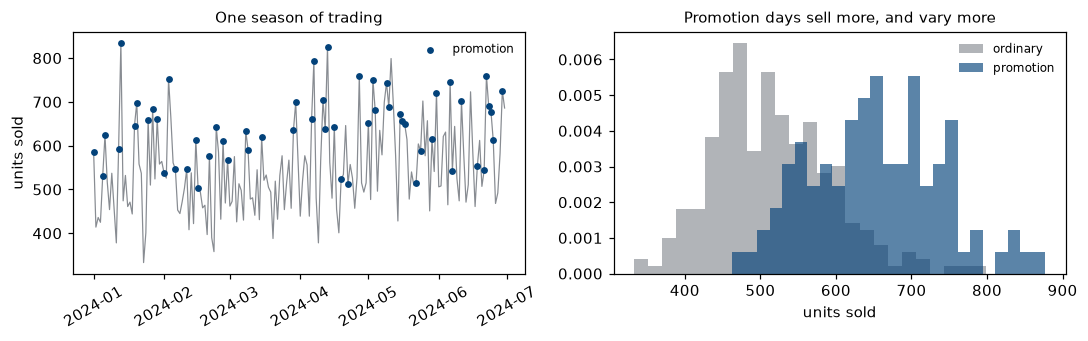

       count   mean   std
promo                    
0        266  515.1  78.0
1         98  653.6  87.8


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

season = history[history.date.dt.year == 2024]
ax[0].plot(season.date, season.units, lw=0.8, color=GREY)
ax[0].scatter(season.date[season.promo == 1], season.units[season.promo == 1],
              s=12, color=ACCENT, zorder=3, label="promotion")
ax[0].set_ylabel("units sold"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("One season of trading", fontsize=10)
ax[0].tick_params(axis="x", rotation=30)

for value, colour, label in [(0, GREY, "ordinary"), (1, ACCENT, "promotion")]:
    ax[1].hist(history.units[history.promo == value], bins=25, alpha=0.65,
               color=colour, label=label, density=True)
ax[1].set_xlabel("units sold"); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("Promotion days sell more, and vary more", fontsize=10)
plt.tight_layout(); plt.show()

print(history.groupby("promo").units.agg(["count", "mean", "std"]).round(1))

Promotion days sell more **and** vary more: the standard deviation rises with the mean.
And ordinary days show a standard deviation near 78 units around a mean near 515. Hold on
to that pair.

---
# Part I. Estimation and uncertainty about parameters

# 2. Poisson regression

Demand is a count, so the natural first model gives each day a Poisson distribution whose
mean depends on that day's characteristics:

$$Y_i \mid \mathbf{x}_i \ \sim\ \operatorname{Poisson}(\mu_i),
\qquad
\mu_i = \exp(\eta_i),
\qquad
\eta_i = \mathbf{x}_i^{\top}\boldsymbol{\beta}.$$

The exponential link keeps the fitted mean positive whatever the coefficients, and makes
each coefficient a **multiplicative** effect: $e^{\beta_j}$ is the factor by which mean
demand changes.

**Estimation is by maximum likelihood.** Equivalently, minimise the average negative
log-likelihood loss

$$J(\boldsymbol{\beta}) = \frac{1}{n} \sum_{i=1}^{n}\bigl(e^{\eta_i} - y_i\eta_i\bigr),$$

which is the empirical risk under the loss $L(z; \boldsymbol{\beta}) = e^{\eta} - y\eta$.
You derive this and minimise it by hand in Homework 1. Here we call `statsmodels`, which
minimises $J$ by iteratively reweighted least squares.

In [5]:
GLM = "units ~ promo + weekend + temp_c20"

poisson_fit = smf.glm(GLM, history, family=sm.families.Poisson()).fit()
print(poisson_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  units   No. Observations:                  364
Model:                            GLM   Df Residuals:                      360
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2827.8
Date:                Wed, 09 Sep 2026   Deviance:                       2694.1
Time:                        13:07:04   Pearson chi2:                 2.70e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2201      0.003   1992.774      0.0

Read the coefficient block as: `coef` is $\widehat{\beta}_j$, `std err` is
$\widehat{\operatorname{se}}(\widehat{\beta}_j)$, `z` is their ratio, and the last two
columns are $\widehat{\beta}_j \pm 1.96\,\widehat{\operatorname{se}}$. Since
$e^{\widehat{\beta}_1} = e^{0.225} = 1.25$, a promotion is associated with higher demand
by about 25%.

## 2.1 Two standard errors for the same estimate

The standard errors above come from the inverse observed information,
$\widehat{\mathbf{V}}_{\text{naive}} = \tfrac{1}{n}\widehat{\mathcal{H}}^{-1}$, which is
the special case of the sandwich

$$\widehat{\mathbf{V}}(\widehat{\boldsymbol{\beta}})
= \tfrac{1}{n}\,\widehat{\mathcal{H}}^{-1}
\widehat{\mathcal{G}}\,\widehat{\mathcal{H}}^{-1}$$

that applies when $\mathcal{G} = \mathcal{H}$.

Asking for `cov_type="HC0"` estimates $\mathcal{G}$ from the observed score contributions
instead of assuming it. You build this estimator yourself in Homework 1.

In [5]:
poisson_robust = smf.glm(GLM, history, family=sm.families.Poisson()).fit(cov_type="HC0")

print(poisson_robust.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  units   No. Observations:                  364
Model:                            GLM   Df Residuals:                      360
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2827.8
Date:                Wed, 02 Sep 2026   Deviance:                       2694.1
Time:                        14:09:21   Pearson chi2:                 2.70e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2201      0.008    732.334      0.0

> **Discussion.** Compare the standard errors under the two methods. What do you notice?
> You will explore this issue in Homework 1.

## 2.2 Negative binomial regression

The Poisson regression model assumes
**equidispersion**, $\operatorname{Var}(Y \mid \mathbf{x}) = \operatorname{E}(Y \mid
\mathbf{x})$, which is often restrictive. We say that there is **overdispersion** when $\operatorname{Var}(Y \mid \mathbf{x}) >\operatorname{E}(Y \mid
\mathbf{x})$.

The negative binomial regression model keeps the same mean model as Poisson regression and adds a dispersion parameter:

$$Y_i \mid \mathbf{x}_i \ \sim\ \operatorname{NegBin}(\mu_i, \alpha),
\qquad
\mu_i = \exp(\mathbf{x}_i^{\top}\boldsymbol{\beta}),
\qquad
\operatorname{Var}(Y_i \mid \mathbf{x}_i) = \mu_i + \alpha\,\mu_i^{2}.$$

Setting $\alpha = 0$ recovers the Poisson, so this model contains the previous one, and
$\alpha$ is estimated alongside $\boldsymbol{\beta}$ by maximum likelihood.

In [6]:
negbin_fit = smf.negativebinomial(GLM, history).fit(disp=0)
negbin_robust = smf.negativebinomial(GLM, history).fit(disp=0, cov_type="HC0")
print(negbin_fit.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  units   No. Observations:                  364
Model:               NegativeBinomial   Df Residuals:                      360
Method:                           MLE   Df Model:                            3
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                 0.07368
Time:                        14:09:21   Log-Likelihood:                -2026.3
converged:                       True   LL-Null:                       -2187.5
Covariance Type:            nonrobust   LLR p-value:                 1.442e-69
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2207      0.008    752.913      0.000       6.204       6.237
promo          0.2261      0.014     16.551      0.000       0.199       0.253
weekend        0.1266      0.013      9.422      0.0

The following table compares the standard errors unders different methods. 

In [7]:
ratios = pd.DataFrame({
    "Poisson naive": poisson_fit.bse,
    "Poisson sandwich": poisson_robust.bse,
    "Poisson ratio": poisson_robust.bse / poisson_fit.bse,
    "NegBin naive": negbin_fit.bse,
    "NegBin sandwich": negbin_robust.bse,
    "NegBin ratio": negbin_robust.bse / negbin_fit.bse,
})
print(ratios[ratios.index != "alpha"].round(4))

           Poisson naive  Poisson sandwich  Poisson ratio  NegBin naive  NegBin sandwich  NegBin ratio
Intercept         0.0031            0.0085         2.7211        0.0083           0.0085        1.0241
promo             0.0048            0.0135         2.8019        0.0137           0.0134        0.9823
temp_c20          0.0004            0.0011         2.7706        0.0011           0.0011        1.0024
weekend           0.0048            0.0134         2.7806        0.0134           0.0133        0.9897


> **Discussion.** Under the Poisson the two standard errors differ by a factor of about
> 2.8. Under the negative binomial the same two standard errors agree to within a few per
> cent. What does that tell you about each model's variance assumption? And note that the
> point estimates barely moved: a wrong conditional variance need not corrupt the estimated mean coefficients if the conditional mean model is correct, but model-based standard errors become invalid.

---
# 3. Quantile regression

The decision needs a quantile. Rather than model the whole distribution and
read a quantile off it, quantile regression targets the quantile directly:

$$q_{\alpha}(Y \mid \mathbf{x}) = \mathbf{x}^{\top}\boldsymbol{\beta}_{\alpha}.$$

Quantile regression does not specify the full conditional distribution of demand. Instead, it models only the conditional quantile we need. The quantile is elicited by the **pinball loss**

$$\rho_{\alpha}(u) = u\bigl(\alpha - \mathbf{1}\{u < 0\}\bigr),
\qquad u = y - \widehat{y},$$

and the estimator is empirical risk minimisation on that loss:

$$\widehat{\boldsymbol{\beta}}_{\alpha}
= \arg\min_{\boldsymbol{\beta}} \frac{1}{n}\sum_{i=1}^{n}
\rho_{\alpha}\bigl(y_i - \mathbf{x}_i^{\top}\boldsymbol{\beta}\bigr).$$

In [8]:
alpha = 2 / 3
QR = "units ~ promo + weekend + temp_c20"

order_rule = smf.quantreg(QR, history).fit(q=alpha)
print(order_rule.summary())

                         QuantReg Regression Results                          
Dep. Variable:                  units   Pseudo R-squared:               0.3927
Model:                       QuantReg   Bandwidth:                       39.40
Method:                 Least Squares   Sparsity:                        185.5
Date:                Wed, 02 Sep 2026   No. Observations:                  364
Time:                        14:09:21   Df Residuals:                      360
                                        Df Model:                            3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    529.1939      6.281     84.256      0.000     516.842     541.546
promo        139.0102     10.417     13.344      0.000     118.524     159.496
weekend       67.0306     10.172      6.590      0.000      47.027      87.034
temp_c20       7.0408      0.847      8.309      0.0

So the order rule is

$$\widehat{q}_{2/3}(\mathbf{x}) = 529 + 139 \cdot \text{promo}
+ 67 \cdot \text{weekend} + 7 \cdot \text{temp\_c20}.$$

A promotion adds about **139 units** to the order, and each degree above 20 adds about 7.

## 3.1 Standard errors via the pairs bootstrap

The pinball loss is piecewise linear, so its second derivative is zero wherever it exists
and the observed Hessian is a zero matrix. The summary reports standard errors using an
analytical approach tailored to quantile regression, which estimates a residual density. 

The bootstrap sidesteps the need for model-specific derivations. The plug-in principle
says: whatever you wanted to compute under $F$, compute it under $\widehat{F}_n$ instead,
where

$$\widehat{F}_n = \frac{1}{n}\sum_{i=1}^{n}\delta_{Z_i},
\qquad Z_i = (Y_i, \mathbf{x}_i),$$

puts mass $1/n$ on each observed **case**. Drawing from $\widehat{F}_n$ therefore means
resampling whole rows, outcome and predictors together. That is the pairs bootstrap.

In [9]:
def bootstrap_quantreg(df, B, seed, formula=QR, q=alpha):
    # One replicate: draw n row indices uniformly with replacement, so some days
    # appear twice and others not at all; refit the same quantile regression on
    # that resampled data set; store the coefficients. B replicates then show how
    # the coefficients would vary if we could redraw the data.
    r = np.random.default_rng(seed)                  # ensures reproducibility
    n, p = len(df), len(order_rule.params)
    out = np.empty((B, p))
    for b in range(B):
        sample = df.iloc[r.integers(0, n, n)]        # samples row indices
        # max_iter is raised because the solver occasionally needs more
        # iterations on a resampled data set. The estimates are unaffected.
        out[b] = smf.quantreg(formula, sample).fit(q=q, max_iter=20_000).params.values
    return pd.DataFrame(out, columns=order_rule.params.index)


boot = bootstrap_quantreg(history, B=2000, seed=SEED)

# The bootstrap standard error is the sample standard deviation of the replicates
# (ddof=1 gives the n-1 denominator). The percentile interval takes the 2.5th and
# 97.5th percentiles of the replicates directly, so it inherits whatever asymmetry
# the sampling distribution has rather than imposing symmetry.
qr_table = pd.DataFrame({
    "estimate": order_rule.params,
    "analytic se": order_rule.bse,
    "bootstrap se": boot.std(ddof=1),
    "boot 2.5%": boot.quantile(0.025),
    "boot 97.5%": boot.quantile(0.975),
})
print(qr_table.round(2))

           estimate  analytic se  bootstrap se  boot 2.5%  boot 97.5%
Intercept    529.19         6.28          5.29     518.50      540.90
promo        139.01        10.42          8.62     117.40      151.83
weekend       67.03        10.17         11.93      47.13       90.83
temp_c20       7.04         0.85          0.63       5.40        8.00


The next cell plots the bootstrap sampling distribution, indicating the 95% confidence
interval.

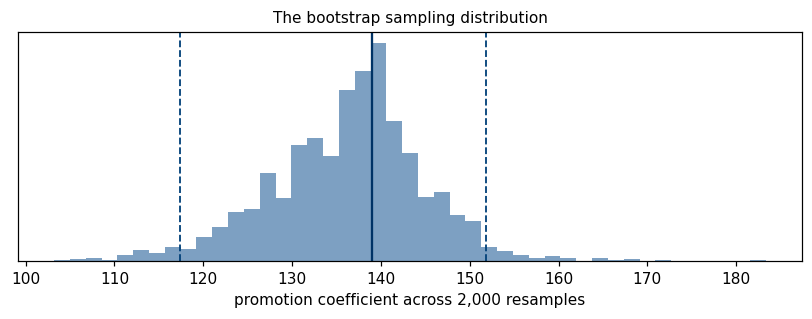

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.hist(boot["promo"], bins=45, color=MUTED, alpha=0.85, density=True)
ax.axvline(order_rule.params["promo"], color=INK, lw=1.5)
for q_ in [0.025, 0.975]:
    ax.axvline(boot["promo"].quantile(q_), color=ACCENT, lw=1.2, ls="--")
ax.set_xlabel("promotion coefficient across 2,000 resamples"); ax.set_yticks([])
ax.set_title("The bootstrap sampling distribution", fontsize=10)
plt.tight_layout(); plt.show()

## 3.2 An interval for the order quantity

The manager asked about the number they have to commit
to commit to. For a given day $\mathbf{x}_*$ the order quantity is a **function of the
coefficients**,

$$\widehat{Q}(\mathbf{x}_*) = \widehat{q}_{2/3}(\mathbf{x}_*)
= \mathbf{x}_*^{\top}\widehat{\boldsymbol{\beta}}_{2/3},$$

so uncertainty about $\widehat{\boldsymbol{\beta}}_{2/3}$ carries straight through to it.
Applying the same linear combination to every bootstrap replicate gives its sampling
distribution directly, with no extra theory.

This is a **confidence interval for the
2/3 quantile of demand**: a statement about a population quantity we estimated. It is not
a statement about how much will be sold tomorrow.

In [11]:
# A promotion weekend at 20 degrees: promo = 1, weekend = 1, temp_c20 = 0.
x_star = pd.DataFrame({"promo": [1], "weekend": [1], "temp_c20": [0.0]})
x_vec = np.array([1.0, 1.0, 1.0, 0.0])              # intercept first, matching params

order_qty = float(x_vec @ order_rule.params.values)
boot_qty = boot.values @ x_vec                       # one order quantity per replicate

print(f"order quantity for a promotion weekend at 20C: {order_qty:.0f} units")
print(f"  bootstrap standard error   {boot_qty.std(ddof=1):.1f} units")
print(f"  95% confidence interval    [{np.percentile(boot_qty, 2.5):.0f}, "
      f"{np.percentile(boot_qty, 97.5):.0f}]")

order quantity for a promotion weekend at 20C: 735 units
  bootstrap standard error   13.8 units
  95% confidence interval    [709, 761]


> **Discussion.** The interval runs from 709 to 761 units around a point estimate of 735,
> roughly 3.5% either way. Suppose instead the manager asked how many units to stock so that she
> is short on no more than one day in three. Is that the same question? Which of the two
> would a wider interval here worry you about more?

**Where the bootstrap fails:** 

Resampling rows assumes the rows are independent draws
from a common distribution. It breaks when observations are dependent, as with repeated
measures, clustered randomisation or serial correlation.  For this exercise, trading days are generated independently conditional on the recorded predictors. Real retail demand commonly has serial dependence, in which case a row-wise pairs bootstrap would not be appropriate.

The bootstrap can also work poorly when the statistic depends on extreme order statistics such as the sample maximum, and when the
sample is so small that $\widehat{F}_n$ is a poor stand-in for $F$.

---
# 4. Bayesian Poisson regression

Same model, different question. Instead of asking how $\widehat{\boldsymbol{\beta}}$
would vary across repeated samples, we ask what we believe about $\boldsymbol{\beta}$
given the data and a prior:

$$Y_i \mid \mathbf{x}_i, \boldsymbol{\beta} \ \sim\
\operatorname{Poisson}\bigl(\exp(\mathbf{x}_i^{\top}\boldsymbol{\beta})\bigr),
\qquad
\beta_0 \sim N(6, 1^{2}),
\qquad
\beta_j \sim N(0, 1^{2}),$$

and the object of interest is the posterior

$$p(\boldsymbol{\beta} \mid \mathcal{D})
\ \propto\ p(\mathcal{D} \mid \boldsymbol{\beta})\, p(\boldsymbol{\beta}).$$

The prior on the intercept is centred at $\log(500) \approx 6.2$, so it says demand is in
the hundreds rather than the millions. The priors on the slopes allow multiplicative
effects up to about $e^{2} \approx 7$, far wider than anything plausible here.

This posterior has no closed form, so we draw from it with MCMC. You meet the sampler
properly in Week 7; for now treat PyMC as a tool that returns draws from
$p(\boldsymbol{\beta} \mid \mathcal{D})$.

**Reading the model block below.** Inside `with pm.Model()`, each line declares one piece
of the model. `pm.Normal("b0", ...)` and `pm.Normal("b", ..., shape=3)` are the priors,
`b` being a vector of three slopes in the order of `predictors`. The line for `mu` builds
$\exp(\beta_0 + \mathbf{X}\boldsymbol{\beta})$ for all 364 days at once. The final line
declares the likelihood: passing `observed=y_train` tells PyMC that this quantity is data
rather than something to sample. `pm.sample` then runs four chains from different
starting points, discards the first 1,000 iterations of each while the sampler adapts,
and keeps the next 1,000, giving 4,000 draws.

In [12]:
import pymc as pm
import arviz as az

predictors = ["promo", "weekend", "temp_c20"]
X_train = history[predictors].to_numpy(float)
y_train = history.units.to_numpy()

with pm.Model() as poisson_bayes:
    b0 = pm.Normal("b0", mu=6.0, sigma=1.0)
    b = pm.Normal("b", mu=0.0, sigma=1.0, shape=len(predictors))
    mu = pm.math.exp(b0 + pm.math.dot(X_train, b))
    pm.Poisson("y", mu=mu, observed=y_train)

    trace = pm.sample(1000, tune=1000, chains=4, cores=4,
                      random_seed=SEED, progressbar=False)

NUTS[nutpie]: [b0, b]


Here is the posterior summary.

In [13]:
print(az.summary(trace, var_names=["b0", "b"], ci_prob=0.95, round_to=4))

        mean      sd  eti95_lb  eti95_ub   ess_bulk   ess_tail   r_hat  mcse_mean  mcse_sd
b0    6.2202  0.0032    6.2140    6.2261  2472.2450  2638.0134  1.0010     0.0001   0.0000
b[0]  0.2250  0.0049    0.2153    0.2345  2447.6086  2789.6785  1.0003     0.0001   0.0001
b[1]  0.1289  0.0049    0.1190    0.1382  3013.1108  2990.2136  1.0004     0.0001   0.0001
b[2]  0.0112  0.0004    0.0105    0.0120  3905.0783  3261.1810  1.0008     0.0000   0.0000


Each row is one parameter. `b0` is the intercept; `b[0]`, `b[1]` and `b[2]` are the slopes
on `promo`, `weekend` and `temp_c20`, in the order they appear in `predictors`. The 4,000
draws are pooled across the four chains before anything is computed.

**The first four columns describe the posterior.** They are the answer.

- **`mean`** — the posterior mean of the parameter: an average over our beliefs about
  $\beta_j$.
- **`sd`** — the posterior standard deviation, measuring how spread out those beliefs are.
- **`eti95_lb`, `eti95_ub`** — the endpoints of a 95% **equal-tailed credible interval**,
  the 2.5th and 97.5th percentiles of the draws. Given the model and the prior, there is a
  95% posterior probability that $\beta_j$ lies inside it. That is a statement about the
  parameter, and it is the statement people wrongly believe a confidence interval makes.

**The last five columns describe the sampler.** We wil discuss how to interpret them in Week 7.

## 4.1 Bayesian negative binomial regression

Section 2.2 showed that the Poisson variance assumption fails. The posterior above has no
mechanism for noticing this: it is a correct probability statement **given the prior and
the model**, and the model asserts equidispersion.

The repair is the same as in Section 2.2, and it is a change to the likelihood rather
than to the computation:

$$Y_i \mid \mathbf{x}_i, \boldsymbol{\beta}, \phi \ \sim\
\operatorname{NegBin}(\mu_i,\ \phi),
\qquad
\operatorname{Var}(Y_i \mid \mathbf{x}_i) = \mu_i + \phi\,\mu_i^{2},
\qquad
\phi \sim \text{Half-Normal}(0, 1^{2}).$$

One implementation note: PyMC's `NegativeBinomial` takes `mu` and a shape parameter
`alpha` with $\operatorname{Var}(Y) = \mu + \mu^{2}/\alpha$. Comparing with the variance
above, $\alpha = 1/\phi$, which is why the code writes `alpha=1 / phi`. Large `alpha`
means little extra dispersion.

In [14]:
with pm.Model() as negbin_bayes:
    b0 = pm.Normal("b0", mu=6.0, sigma=1.0)
    b = pm.Normal("b", mu=0.0, sigma=1.0, shape=len(predictors))
    phi = pm.HalfNormal("phi", sigma=1.0)
    mu = pm.math.exp(b0 + pm.math.dot(X_train, b))
    pm.NegativeBinomial("y", mu=mu, alpha=1 / phi, observed=y_train)

    trace_nb = pm.sample(1000, tune=1000, chains=4, cores=4,
                         random_seed=SEED, progressbar=False)

print(az.summary(trace_nb, var_names=["b0", "b", "phi"], ci_prob=0.95, round_to=4))

NUTS[nutpie]: [b0, b, phi]


        mean      sd  eti95_lb  eti95_ub   ess_bulk   ess_tail   r_hat  mcse_mean  mcse_sd
b0    6.2208  0.0083    6.2048    6.2367  2918.7638  3044.4352  1.0000     0.0002   0.0001
b[0]  0.2258  0.0138    0.1990    0.2528  3455.9777  3006.8628  1.0008     0.0002   0.0002
b[1]  0.1266  0.0135    0.1000    0.1538  3351.6090  3178.7959  1.0015     0.0002   0.0002
b[2]  0.0114  0.0011    0.0092    0.0136  4639.9409  3104.8164  1.0001     0.0000   0.0000
phi   0.0120  0.0010    0.0101    0.0141  4930.5598  3209.1039  1.0000     0.0000   0.0000


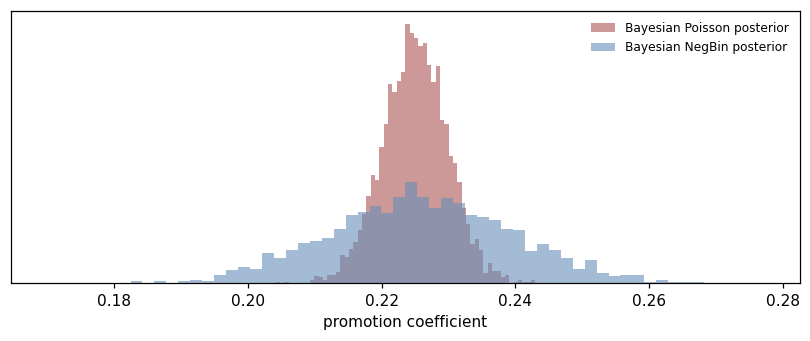

In [15]:
def posterior_draws(idata):
    # PyMC stores draws with shape (chains, draws, ...), here (4, 1000) for b0 and
    # (4, 1000, 3) for b. Flattening the first two axes pools the chains, giving one
    # (4000 x 4) array whose columns are intercept, promo, weekend, temp_c20.
    return np.column_stack([idata.posterior["b0"].values.reshape(-1, 1),
                            idata.posterior["b"].values.reshape(-1, 3)])


post_b = posterior_draws(trace)
post_nb = posterior_draws(trace_nb)
phi_post = trace_nb.posterior["phi"].values.reshape(-1)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(post_b[:, 1], bins=60, density=True, color=FLAG, alpha=0.55,
        label="Bayesian Poisson posterior")
ax.hist(post_nb[:, 1], bins=60, density=True, color=MUTED, alpha=0.6,
        label="Bayesian NegBin posterior")
ax.set_xlabel("promotion coefficient"); ax.set_yticks([])
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
# Part II. Uncertainty about outcomes

# 5. Four ways to obtain predictive intervals

Everything so far was an interval for a **population quantity**, including the order
quantity in Section 3.2. The manager's second question was about an **outcome**. Here are
the four constructions, for a new day with characteristics $\mathbf{x}_*$.

**1. Plug-in.** Put $\widehat{\boldsymbol{\beta}}$ into the fitted model and read off
quantiles, treating the estimate as though it were the truth:

$$Y_* \sim \operatorname{Poisson}\bigl(\exp(\mathbf{x}_*^{\top}
\widehat{\boldsymbol{\beta}})\bigr).$$

**2. Asymptotic.** Restore parameter uncertainty by adding a step. For $s = 1,\dots,S$,

$$\boldsymbol{\beta}^{(s)} \sim
N\bigl(\widehat{\boldsymbol{\beta}},\ \widehat{\mathbf{V}}\bigr),
\qquad
Y_*^{(s)} \sim p\bigl(\cdot \mid \mathbf{x}_*;\ \boldsymbol{\beta}^{(s)}\bigr),$$

then take the empirical quantiles of the $Y_*^{(s)}$.

**3. Quantile regression.** No model and no draws. Read two fitted quantiles directly:

$$\bigl[\widehat{q}_{0.05}(\mathbf{x}_*),\ \widehat{q}_{0.95}(\mathbf{x}_*)\bigr].$$

**4. Posterior predictive.** The same two steps as the asymptotic route, with the draws
coming from the posterior rather than a normal approximation:

$$p(y_* \mid \mathbf{x}_*, \mathcal{D})
= \int p(y_* \mid \mathbf{x}_*, \boldsymbol{\beta})\,
p(\boldsymbol{\beta} \mid \mathcal{D})\, d\boldsymbol{\beta}.$$

Constructions 1, 2 and 4 need a model $p(y \mid \mathbf{x}, \boldsymbol{\beta})$ to draw
$Y_*$ from. Construction 3 does not. We run construction 4 twice, once under each of the
two Bayesian models, which gives five intervals in all.

In [16]:
S = 4000                      # number of simulation draws per construction

def design(df):
    # Build the design matrix by hand, in the SAME column order that statsmodels
    # and PyMC used: intercept, promo, weekend, temp_c20.
    return np.column_stack([np.ones(len(df)), df.promo, df.weekend, df.temp_c20])


def plug_in(df, level=0.90):
    # Fitted mean for each row, then the 5th and 95th percentiles of a Poisson with
    # that mean. `ppf` is the inverse CDF.
    mu = poisson_fit.predict(df).values
    tail = (1 - level) / 2
    return stats.poisson.ppf(tail, mu), stats.poisson.ppf(1 - tail, mu)


def asymptotic(df, level=0.90, seed=SEED):
    # Step 1: S draws of beta from the asymptotic normal approximation, using the
    #         SANDWICH covariance. Shape (S, 4).
    r = np.random.default_rng(seed)
    betas = r.multivariate_normal(poisson_robust.params.values,
                                  poisson_robust.cov_params().values, S)
    # Step 2: design(df) @ betas.T is (n rows x S draws) of linear predictors, so
    #         exponentiating gives one mean per row per draw, and r.poisson draws one
    #         outcome for each. Percentiles across draws (axis=1) give one interval
    #         per row.
    draws = r.poisson(np.exp(design(df) @ betas.T))
    tail = 100 * (1 - level) / 2
    return np.percentile(draws, tail, axis=1), np.percentile(draws, 100 - tail, axis=1)


# Two more quantile regressions on the same history, at the 5% and 95% levels.
lo_q = smf.quantreg(QR, history).fit(q=0.05, max_iter=20_000)
hi_q = smf.quantreg(QR, history).fit(q=0.95, max_iter=20_000)

def quantile_route(df, level=0.90):
    return lo_q.predict(df).values, hi_q.predict(df).values


def posterior_predictive(df, post, phi_draws=None, level=0.90, seed=SEED):
    # Identical two-step recipe to `asymptotic`, with one change: the beta draws come
    # from the posterior instead of a normal approximation. If phi is supplied, its
    # draw is carried along with the beta draw it belongs to.
    r = np.random.default_rng(seed)
    idx = r.integers(0, len(post), S)
    mu = np.exp(design(df) @ post[idx].T)                    # n rows x S draws
    if phi_draws is None:
        draws = r.poisson(mu)
    else:
        # numpy parameterises the negative binomial by (n_successes, p_success),
        # which for mean mu and variance mu + phi*mu^2 means n = 1/phi and
        # p = 1/(1 + phi*mu).
        p = phi_draws[idx]
        draws = r.negative_binomial(1 / p, 1 / (1 + p * mu))
    tail = 100 * (1 - level) / 2
    return np.percentile(draws, tail, axis=1), np.percentile(draws, 100 - tail, axis=1)


builders = [
    ("plug-in (Poisson MLE)", lambda d: plug_in(d)),
    ("asymptotic (Poisson MLE)", lambda d: asymptotic(d)),
    ("quantile regression", lambda d: quantile_route(d)),
    ("posterior predictive (Poisson)", lambda d: posterior_predictive(d, post_b)),
    ("posterior predictive (NegBin)", lambda d: posterior_predictive(d, post_nb, phi_post)),
]
print("interval builders ready")

interval builders ready


## 5.1 Five intervals

Take the same day as Section 3.2, a promotion weekend at 20 degrees, so that the
predictive intervals below can be compared directly.

In [17]:
rows = []
for name, fn in builders:
    lo, hi = fn(x_star)
    rows.append({"construction": name, "lower": lo[0], "upper": hi[0],
                 "width": hi[0] - lo[0]})
print("90% predictive intervals for one promotion weekend at 20C\n")
print(pd.DataFrame(rows).set_index("construction").round(0))
print(f"\nfor contrast, Section 3.2's confidence interval for the ORDER QUANTITY "
      f"on this day\nwas [{np.percentile(boot_qty, 2.5):.0f}, "
      f"{np.percentile(boot_qty, 97.5):.0f}], width "
      f"{np.percentile(boot_qty, 97.5) - np.percentile(boot_qty, 2.5):.0f} units")

90% predictive intervals for one promotion weekend at 20C

                                lower  upper  width
construction                                       
plug-in (Poisson MLE)           673.0  761.0   88.0
asymptotic (Poisson MLE)        670.0  764.0   94.0
quantile regression             580.0  840.0  260.0
posterior predictive (Poisson)  672.0  762.0   90.0
posterior predictive (NegBin)   583.0  857.0  274.0

for contrast, Section 3.2's confidence interval for the ORDER QUANTITY on this day
was [709, 761], width 52 units


> **Pause and think.** The confidence interval for the order quantity is far narrower than
> any of the predictive intervals. Why should we expect the predictive interval to be much wider in this example?
>
> Then look at the first two rows. The asymptotic route added parameter uncertainty to the
> plug-in route and almost nothing happened. Before running the audit, decide which
> explanation you believe: that parameter uncertainty is genuinely small here, or that
> something else dominates.

---
# 6. Auditing the intervals

Now use the held-out file. Count how often each interval contained the outcome. A coverage
estimate is itself an estimate, so it carries a standard error,
$\sqrt{\alpha(1-\alpha)/n_{\text{test}}}$: each day either falls inside its interval or
does not, so the count is binomial. Report it, or you cannot tell a real shortfall from a
run of ordinary luck.

In [18]:
promo_mask = (new_days.promo == 1).values

def audit(lo, hi):
    covered = (new_days.units.values >= lo) & (new_days.units.values <= hi)
    return {"coverage": covered.mean(),
            "coverage, promo days": covered[promo_mask].mean(),
            "mean width": np.mean(hi - lo)}

results = pd.DataFrame([{"construction": name, **audit(*fn(new_days))}
                        for name, fn in builders]).set_index("construction")
print(f"target 90%, audited on {len(new_days)} held-out days "
      f"({promo_mask.sum()} with promotions)\n")
print(results.round(3))
print(f"\nstandard error on a coverage estimate: "
      f"{np.sqrt(0.9 * 0.1 / len(new_days)):.3f} overall, "
      f"{np.sqrt(0.9 * 0.1 / promo_mask.sum()):.3f} on promotion days")

target 90%, audited on 1456 held-out days (319 with promotions)

                                coverage  coverage, promo days  mean width
construction                                                              
plug-in (Poisson MLE)              0.456                 0.433      76.611
asymptotic (Poisson MLE)           0.467                 0.442      79.652
quantile regression                0.885                 0.887     212.143
posterior predictive (Poisson)     0.453                 0.426      76.975
posterior predictive (NegBin)      0.883                 0.878     211.059

standard error on a coverage estimate: 0.008 overall, 0.017 on promotion days


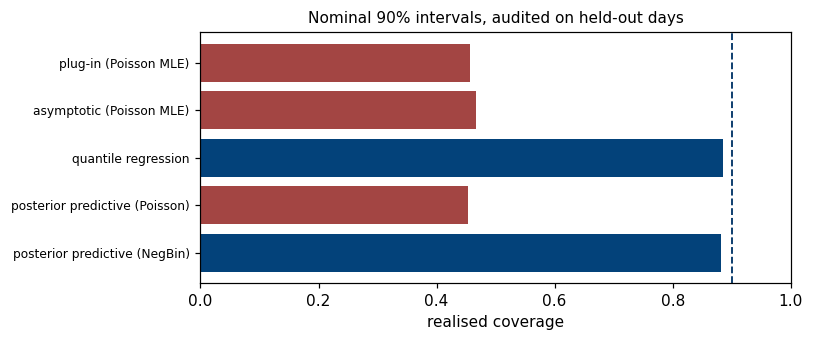

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
order = results.index[::-1]
ax.barh(range(len(order)), results.loc[order, "coverage"],
        color=[FLAG if c < 0.8 else ACCENT for c in results.loc[order, "coverage"]])
ax.axvline(0.90, color=INK, lw=1.2, ls="--")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("realised coverage"); ax.set_xlim(0, 1)
ax.set_title("Nominal 90% intervals, audited on held-out days", fontsize=10)
plt.tight_layout(); plt.show()

Three of the five cover less than half the time, and they are exactly the three that
assume a Poisson outcome. The posterior predictive calculation propagates parameter uncertainty exactly under the Poisson model. That does not make the Poisson model's uncertainty calibrated when the likelihood understates the conditional variance.
Parameter uncertainty was not the problem: the **model's conditional variance** was.

The two that work take opposite routes to it. Quantile regression never imposed a full parametric distribution for $Y \mid X$. The negative binomial assumed one, but a family wide enough to hold
the dispersion the data actually show.

> **Discussion.** For each construction, identify:
> - what is assumed about $Y\mid X$;
> - how parameter uncertainty is handled;
> - what would have to be true for the resulting interval to have approximately 90% coverage.

---
# 7. Conformal prediction

Section 6 audited five intervals and **guaranteed** none of them. Conformal prediction
supplies a guarantee that holds in finite samples, with no model, provided the cases are
exchangeable. Here is the construction:

1. Hold out a **calibration set** of size $n_c$, not used in fitting.
2. **Score** each calibration case by how far its outcome fell outside the base interval,
   $$s_i = \max\bigl\{\widehat{q}_{\text{lo}}(\mathbf{x}_i) - y_i,\ \
   y_i - \widehat{q}_{\text{hi}}(\mathbf{x}_i)\bigr\}.$$
3. **Widen** the base interval at both ends by $\widehat{w} = s_{(k)}$, the $k$-th
   smallest score, where $k = \lceil (n_c+1)(1-\alpha)\rceil$.

Nothing in that recipe asks whether the base rule is any good. So we put it to the hardest
test available: wrap the **Poisson plug-in interval**, which Section 6 showed covers
barely 44% of the time, and see what the guarantee does to it. For comparison we also wrap
the quantile-regression interval, which gives **conformalised quantile regression (CQR)**.

We randomly split the historical sample so that both fitting and calibration sets span the January–June season. For the finite-sample conformal guarantee, however, the calibration and future cases must be exchangeable. That is built into this exercise; in real time-ordered retail data, serial dependence or distributional drift can invalidate the standard guarantee.

In [20]:
idx = np.arange(len(history))
np.random.default_rng(SEED).shuffle(idx)
n_fit = len(history) // 2
fit_set, calib_set = history.iloc[idx[:n_fit]], history.iloc[idx[n_fit:]]
n_cal = len(calib_set)
k = int(np.ceil((n_cal + 1) * 0.90))

print(f"fitting set {n_fit} days, calibration set {n_cal} days")
print(f"k = ceil((n_c+1)(1-alpha)) = {k}, so we take the {k}/{n_cal} = "
      f"{k / n_cal:.3f} empirical quantile of the scores")
print(f"finite-sample target implied by the rank correction k/(n_c+1) = {k / (n_cal + 1):.4f}  (cannot be exactly 0.900)")
print(f"\nrealised coverage for THIS calibration set will scatter around that level")
print(f"with a standard deviation of about {np.sqrt(0.9 * 0.1 / n_cal):.3f}")

fitting set 182 days, calibration set 182 days
k = ceil((n_c+1)(1-alpha)) = 165, so we take the 165/182 = 0.907 empirical quantile of the scores
finite-sample target implied by the rank correction k/(n_c+1) = 0.9016  (cannot be exactly 0.900)

realised coverage for THIS calibration set will scatter around that level
with a standard deviation of about 0.022


In [21]:
def conformalise(lo_fn, hi_fn, label):
    # Score the calibration cases: positive when the outcome landed outside the base
    # interval, negative when inside. Widen by the k-th smallest score (np.sort is
    # ascending and Python indexes from zero, hence k-1). w may be negative.
    s = np.maximum(lo_fn(calib_set) - calib_set.units.values,
                   calib_set.units.values - hi_fn(calib_set))
    w = np.sort(s)[k - 1]

    lo0, hi0 = lo_fn(new_days), hi_fn(new_days)          # base rule, unconformalised
    lo, hi = lo0 - w, hi0 + w                            # after calibration
    before = (new_days.units.values >= lo0) & (new_days.units.values <= hi0)
    after = (new_days.units.values >= lo) & (new_days.units.values <= hi)
    return {"base rule": label,
            "coverage before": before.mean(),
            "widening": w,
            "coverage after": after.mean(),
            "coverage after, promo": after[promo_mask].mean(),
            "width, ordinary": np.mean((hi - lo)[~promo_mask]),
            "width, promo": np.mean((hi - lo)[promo_mask])}


# Both base rules are refitted on the FITTING half only, so the calibration half is
# untouched by fitting and the scores stay exchangeable.
pois_fit_half = smf.glm(GLM, fit_set, family=sm.families.Poisson()).fit()

def pois_interval(d):
    mu = pois_fit_half.predict(d).values
    return stats.poisson.ppf(0.05, mu), stats.poisson.ppf(0.95, mu)

lo_cqr = smf.quantreg(QR, fit_set).fit(q=0.05, max_iter=20_000)
hi_cqr = smf.quantreg(QR, fit_set).fit(q=0.95, max_iter=20_000)

conf = pd.DataFrame([
    conformalise(lambda d: pois_interval(d)[0], lambda d: pois_interval(d)[1],
                 "Poisson plug-in interval"),
    conformalise(lambda d: lo_cqr.predict(d).values,
                 lambda d: hi_cqr.predict(d).values,
                 "quantile regression (CQR)"),
]).set_index("base rule")
print(conf.round(3))

                           coverage before  widening  coverage after  coverage after, promo  width, ordinary  width, promo
base rule                                                                                                                 
Poisson plug-in interval             0.441    66.000           0.882                   0.84          207.150       215.884
quantile regression (CQR)            0.870     1.333           0.874                   0.85          201.493       239.284



Look at the first row. The Poisson plug-in interval went in covering about 44% of days,
and came out covering about 88%. Conformal prediction repaired an interval built on a
model whose variance assumption is wrong by a factor of eight, and it did so knowing
nothing about the model: it simply measured how badly the base rule missed on the
calibration set and widened by that amount.

**This is the whole point of the method.** The guarantee attaches to the *procedure*, not
to the model. Any base rule, however wrong, can be conformalised into one with valid
marginal coverage.

Now read the rest of the row. Promotion-day coverage sits several points below the
marginal figure, and the widths on promotion and ordinary days are nearly the same. The
Poisson interval scales its width like $\sqrt{\mu}$, but the true spread scales like
$\mu$, so the shape is wrong on every day and adding a constant cannot fix it. Conformal
corrected the average level and left the shape untouched.

**Conformal guarantees average coverage across exchangeable cases. It does not generally guarantee 90% coverage for every subgroup or every value of $\mathbf x$.**

CQR starts from a base rule that already tracks the conditional spread. It needed a
widening of barely one unit, and its widths differ by nearly 40 units between promotion
and ordinary days. Both rules now cover about 88% marginally, but they got there by
different routes: one was rescued, the other was already close.

> **Discussion.** State precisely what the theorem promises and what it does not. Then say
> what changed between the two rows and what did **not** change. Finally: if conformal can
> rescue any base rule, why fit a good one?

**In practice.** You would not normally write this yourself. MAPIE implements split
conformal, CQR, cross-conformal and jackknife-plus for any scikit-learn regressor; crepes
implements conformal predictive systems, which give a full predictive distribution rather
than an interval. Both wrap the same three steps you just ran. Knowing the mechanism lets
you read their documentation and tell which assumption each variant needs.

---
# What you can now do

- Fit **Poisson and negative binomial regressions** by maximum likelihood, and read a
  naive-to-sandwich ratio as a statement about the variance assumption rather than about
  the estimate.
- Fit a **quantile regression**, and explain why its standard errors need a bandwidth
  while the bootstrap does not.
- Write a **pairs bootstrap**, carry it through to a derived quantity such as the order
  quantity, and separate statistical error from Monte Carlo error.
- Fit a **Bayesian GLM**, read a posterior summary, and know that clean convergence
  diagnostics say nothing about whether the model is right.
- Build **predictive intervals four ways**, and say for each what it assumes and what it
  ignores.
- Distinguish an interval for an **estimand** from an interval for an **outcome**, and
  explain why the second is wider.
- Build a **conformal** interval, state precisely what its guarantee covers, and audit
  coverage within the groups where the money sits.
- Attach a **standard error to a coverage estimate**, and refuse to read a gap smaller
  than its own noise.

### A lesson to carry

Every uncertainty statement has a target, assumptions, and a remainder. The methods differ in what they target, which assumptions they require, and what uncertainty remains outside the calculation.